# Assignment 2: Probabilty and Statistics

# Due 11:59pm Sunday the 21st of September 2025

### Submission Instructions: Share this notebook to <fortino@udel.edu> with edit permissions.

# Assignment Instructions

1. In order to start working on this assignment you must go to `File` -> `Save a copy in Drive`. Then, you can edit and rename the new copy of this notebook which you will submit.

2. Your submission notebook must follow specific name conventions. Your submission will not be graded until the naming conventions are followed exactly.

The name of first assignment file is `FDSFE_Assignment_01.ipynb`. When you make a copy of it, the new file will be named `Copy of FDSFE_Assignment_01.ipynb`. You will rename this file in the following fashion: First you will include the first letter of your first name, capitalized. Next you will include your surname, also capitalized. Finally you will include an underscore followed by the original name of the assignment.

For example: My first name is Willow and my last name is Fortino, so I would rename the first assignment as `WFORTINO_FDSFE_Assignment_01.ipynb`.

3. The first cell after the instructions in your assignment submission must always be a text cell containing your Collaboration Statement and AI Use Statement.

4. In some tasks in these assignments you will be given some pre-written code that is incomplete. You will be required to fill in the missing code. In these cases, you will see the following placeholder code:

```
# YOUR CODE HERE
raise NotImplementedError()
```

You will delete this and replace it with your own code which completes the task.

# Collaboration Statement

Who did you work with on this assignment, and what did each of you do?


# AI Use

Did you use generative AI (like ChatGPT, Google Gemini, etc.)? What did you use it for? Be specific.

In [6]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

# Task 1 (4 points): The Law of Large Numbers

The Law of Large Numbers is:
> "As the size of a sample tends to infinity, the mean of the sample approaches the mean of the population."

Objectives:
1. Generate 100,000 random numbers from a standard normal distribution. These 100,000 numbers will be our "population".
2. Generate a random sample from this population of size 10. Let this be "Sample 1".
3. Generate a random sample from this population of size 1,000. Let this be "Sample 2".
4. Generate a random sample from this population of size 50,000. Let this be "Sample 3".
5. In one figure, plot the following:
    1. A histogram of the population.
    2. A histogram of Sample 1.
    3. A histogram of Sample 2.
    4. A histogram of Sample 3.
    5. The probability density function (PDF) of the standard normal distribution.
6. Ensure that your figure has the following qualities:
    1. Appropriate axis labels.
    2. All five plots are easily visually identified and distinguished from one another.
    3. All five plots are labelled and a legend is present.
    4. Axis tick marks are legible and appropriate.
7. Write a figure caption that explains what the figure is and why it is a demonstration of the Law of Large Numbers.

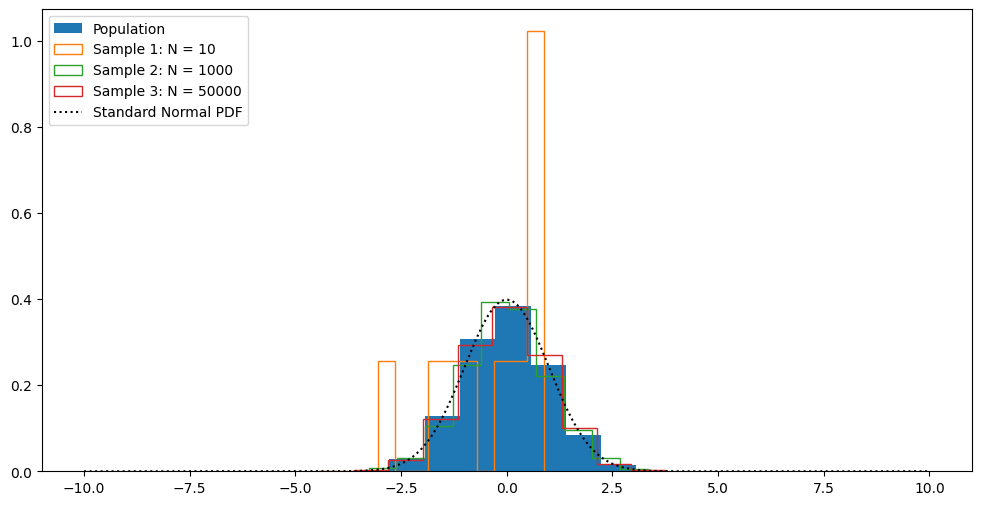

In [7]:
population = stats.norm.rvs(loc=0, scale=1, size=100_000)
sample1 = np.random.choice(population, size=10)
sample2 = np.random.choice(population, size=1_000)
sample3 = np.random.choice(population, size=50_000)

support = np.linspace(-10, 10, num=100_000)
pdf = stats.norm.pdf(support, loc=0, scale=1)

nbins = 10
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(population, bins=nbins, density=True, label="Population")
ax.hist(sample1, bins=nbins, histtype="step", density=True, label="Sample 1: N = 10")
ax.hist(sample2, bins=nbins, histtype="step", density=True, label="Sample 2: N = 1000")
ax.hist(sample3, bins=nbins, histtype="step", density=True, label="Sample 3: N = 50000")

ax.plot(support, pdf, c="k", ls=":", label="Standard Normal PDF")

ax.legend(loc="upper left")
fig.show()

# Task 2 (6 points): The Central Limit Theorem

The Central Limit Theorem is:

* Let the set $(X_1, X_2, X_3, \ldots, X_N)$ be a random sample of size $N$ from some population.
* And let the distribution of that population have mean $\mu$ and variance $\sigma^2$.
* Let the mean of the sample be $\bar{X}_N$.
* Then $\bar{X}_N$ is a random variable described by a Gaussian distribution with mean $\mu$ and variance $\frac{\sigma^2}{N}$.

An alternative explanation of the Central Limit Theorem (CLT) from wikipedia:

> “In other words, suppose that a large sample of observations is obtained, each observation being randomly produced in a way that does not depend on the values of the other observations, and the average of the observed values is computed.

> “If this procedure is performed many times, resulting in a collection of observed averages, the central limit theorem says that if the sample size is large enough, the probability distribution of these averages will closely approximate a normal distribution.”


You can generate random numbers from a [binomial distribution](https://en.wikipedia.org/wiki/Binomial_distribution) using [`scipy.stats.binom`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html).

* The binomial distribution is a discrete distribution.
* The binomial distribution takes two parameters: $n$ and $p$.
* What type of situation does the binomial distribution describe:
    * Consider a generic "experiment" that you can perform $n$ times. The outcome of the experiment can either be a "success" or a "failure".
    * A success has a probability $p$ of occurring for each experiment.
    * A failure has a probability of $q=1-p$ occurring for each experiment.
    * The binomial distribution is the distribution of $k$ successes within $n$ experiments.
* When $p=\frac{1}{2}$, the binomial distribution describes the number of heads you will see after flipping a fair coin $n$ times.

![Binom](https://upload.wikimedia.org/wikipedia/commons/thumb/7/75/Binomial_distribution_pmf.svg/2560px-Binomial_distribution_pmf.svg.png)

The number of $k$ successes is the horizontal axis, and the probability of getting $k$ successes on the vertical axis. The blue plot shows the probability of getting of $k$ heads for a fair coin ($p = 0.5$) when flipping that coin 20 times.

The red plot shows the probability of getting $k$ heads for a fair coin when flipping that coin 40 times. Notice how the distribution shifts to the right compared to the blue plot, indicating that more successes are more common (because the coin was flipped 40 times instead of only 20).

Objectives:
1. Generate 100,000 random numbers from a binomial distribution with $p=0.5$ and $n=100$. This is our population.
2. The mean of a binomial distribution is $\mu = np$ and the variance is $\sigma^2 = n p q = n p (1-p)$. Caculate the mean and variance of this binomial distribution with $p = 0.5$ and $n = 100$. Save these values in variables called `mu_true` and `var_true`.
3. Calculate the empirical mean and variance of the particular population you have generated. Save these values in variables called `mu_pop` and `var_pop`.
4. Generate 1000 random samples from the population, each of size $N = 100$.
5. Calculate the mean of each of these samples of size $N$.
5. Calculate the mean and variance of this collection of means, and save these values in variables called `mu_sample` and `var_sample`.
7. In one figure, plot the following:
    1. The histogram of the collection of means. Use the `density=True`.
    2. The probability density function (PDF) of a Guassian distribution with a mean equal to `mu_sample` and a variance of `var_sample`.
8. Ensure that your figure has the following qualities:
    1. Appropriate axis labels.
    3. Both plots are labelled and a legend is present.
    4. Axis tick marks are legible and appropriate.
9. Write a figure caption that explains what the figure is and why it is a demonstration of the Central Limit Theorem (CLT).

In [8]:
n = 50
p = 0.5
population = stats.binom.rvs(n, p, size=100_000)

mu_true = n * p
var_true = n * p * (1 - p)

mu_pop = np.mean(population)
var_pop = np.var(population)

print(mu_true, mu_pop)
print(var_true, var_pop)

25.0 25.0037
12.5 12.46424631


In [9]:
N = 100
N_samples = 10000

samples = np.random.choice(population, size=(N_samples, N))
sample_means = np.mean(samples, axis=1)

mu_sample = np.mean(sample_means)
var_sample = np.var(sample_means)
print(mu_sample)
print(var_sample)

25.000434
0.123779711644


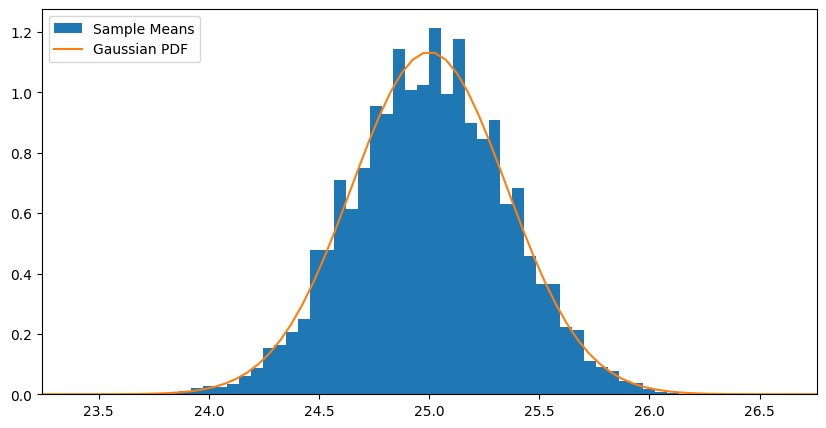

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sample_means, bins=50, density=True, label=f"Sample Means")
# ax.axvline(x=mu_sample, c="k", ls=":", label="Mean of sample means")

# support = np.arange(n+1)
# pmf = stats.binom.pmf(support, n, p)
# ax.plot(support, pmf, label=f"Binomial PMF; $n = {n}$, $p = {p}$")

support = np.linspace(0, n, num=1000)
pdf = stats.norm.pdf(support, loc=mu_sample, scale=np.sqrt(var_sample))
ax.plot(support, pdf, label=f"Gaussian PDF")

ax.set_xlim((mu_sample - 5*np.sqrt(var_sample), mu_sample + 5*np.sqrt(var_sample)))

ax.legend(loc="upper left")
fig.show()